In [1]:
import torch
print(torch.__version__)          
print(torch.cuda.is_available())  
print(torch.cuda.get_device_name(0))  

2.9.0+cu128
True
Tesla T4


In [11]:
import pandas as pd
from datasets import load_dataset

In [12]:
train_data = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="train")
val_data = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="dev")
test_data = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="test")

train_df = train_data.to_pandas()
val_df = val_data.to_pandas()
test_df = test_data.to_pandas()

print("Sample data (first 5 rows):")
print(train_df.head())

Sample data (first 5 rows):
                        id                                               text  \
0  eng_train_track_b_00001                       Colorado, middle of nowhere.   
1  eng_train_track_b_00002  This involved swimming a pretty large lake tha...   
2  eng_train_track_b_00003        It was one of my most shameful experiences.   
3  eng_train_track_b_00004  After all, I had vegetables coming out my ears...   
4  eng_train_track_b_00005                        Then the screaming started.   

   anger  disgust  fear  joy  sadness  surprise  
0      0      NaN     1    0        0         1  
1      0      NaN     2    0        0         0  
2      0      NaN     1    0        3         0  
3      0      NaN     0    0        0         0  
4      0      NaN     3    0        1         2  


In [13]:
EMOTIONS = ["anger", "fear", "joy", "sadness", "surprise"]

def convert_two_step_labels(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1️⃣ Drop disgust
    if "disgust" in df.columns:
        df = df.drop(columns=["disgust"])
    
    for e in EMOTIONS:
        df[f"{e}_intensity"] = df[e].copy()

    for e in EMOTIONS:
        df[e] = (df[e] > 0).astype(int)

    return df

train_two = convert_two_step_labels(train_df)
val_two = convert_two_step_labels(val_df)    
test_two = convert_two_step_labels(test_df)
print(train_two.head())


                        id                                               text  \
0  eng_train_track_b_00001                       Colorado, middle of nowhere.   
1  eng_train_track_b_00002  This involved swimming a pretty large lake tha...   
2  eng_train_track_b_00003        It was one of my most shameful experiences.   
3  eng_train_track_b_00004  After all, I had vegetables coming out my ears...   
4  eng_train_track_b_00005                        Then the screaming started.   

   anger  fear  joy  sadness  surprise  anger_intensity  fear_intensity  \
0      0     1    0        0         1                0               1   
1      0     1    0        0         0                0               2   
2      0     1    0        1         0                0               1   
3      0     0    0        0         0                0               0   
4      0     1    0        1         1                0               3   

   joy_intensity  sadness_intensity  surprise_intensity  
0   

In [17]:
train_presence = train_two[EMOTIONS].sum()
val_presence   = val_two[EMOTIONS].sum()
test_presence  = test_two[EMOTIONS].sum()

print("Train Presence Distribution:\n", train_presence)
print("\nValidation Presence Distribution:\n", val_presence)
print("\nTest Presence Distribution:\n", test_presence)

Train Presence Distribution:
 anger        333
fear        1610
joy          674
sadness      875
surprise     839
dtype: int64

Validation Presence Distribution:
 anger       16
fear        62
joy         31
sadness     34
surprise    31
dtype: int64

Test Presence Distribution:
 anger        322
fear        1543
joy          670
sadness      880
surprise     799
dtype: int64


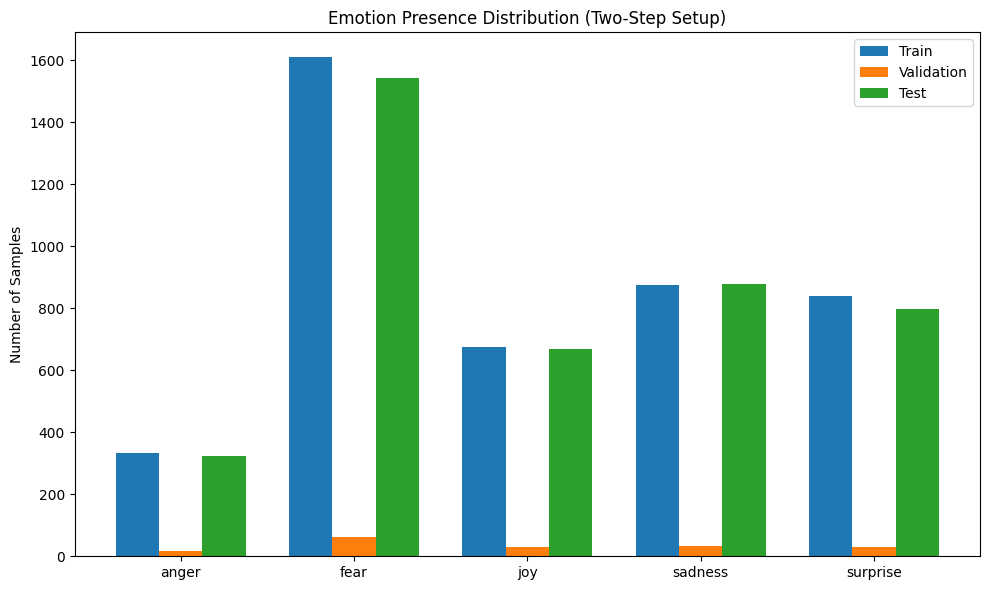

In [18]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(EMOTIONS))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, train_presence, width, label="Train")
plt.bar(x, val_presence, width, label="Validation")
plt.bar(x + width, test_presence, width, label="Test")

plt.xticks(x, EMOTIONS)
plt.ylabel("Number of Samples")
plt.title("Emotion Presence Distribution (Two-Step Setup)")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
def get_intensity_counts(df):
    intensity_cols = [f"{e}_intensity" for e in EMOTIONS]
    intensities = pd.concat([df[col] for col in intensity_cols])
    return intensities.value_counts().sort_index()

train_intensity = get_intensity_counts(train_two)
val_intensity   = get_intensity_counts(val_two)
test_intensity  = get_intensity_counts(test_two)
print("Train Intensity Distribution:\n", train_intensity)
print("\nValidation Intensity Distribution:\n", val_intensity)  
print("\nTest Intensity Distribution:\n", test_intensity)

Train Intensity Distribution:
 0    9484
1    2605
2    1256
3     470
Name: count, dtype: int64

Validation Intensity Distribution:
 0    401
1    102
2     59
3     13
Name: count, dtype: int64

Test Intensity Distribution:
 0    9611
1    2535
2    1192
3     487
Name: count, dtype: int64


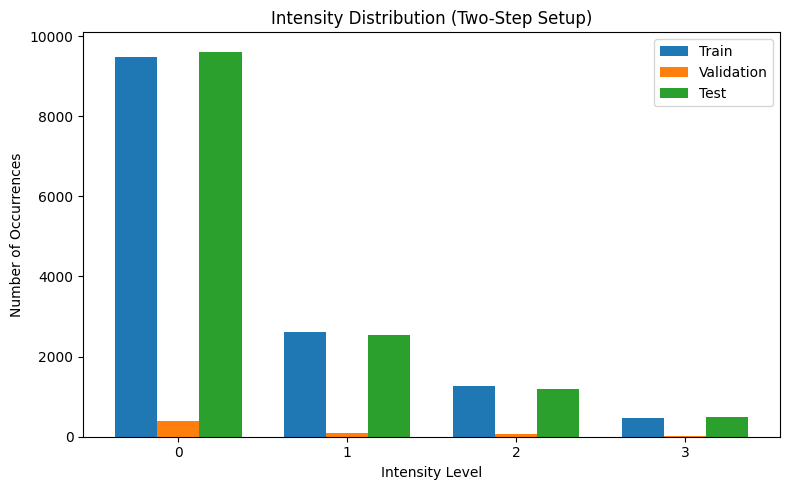

In [22]:
levels = [0,1,2,3]
x = np.arange(len(levels))

plt.figure(figsize=(8,5))

plt.bar(x - width, train_intensity.reindex(levels, fill_value=0), width, label="Train")
plt.bar(x, val_intensity.reindex(levels, fill_value=0), width, label="Validation")
plt.bar(x + width, test_intensity.reindex(levels, fill_value=0), width, label="Test")

plt.xticks(x, levels)
plt.xlabel("Intensity Level")
plt.ylabel("Number of Occurrences")
plt.title("Intensity Distribution (Two-Step Setup)")
plt.legend()
plt.tight_layout()
plt.show()